## Settings 

In [ ]:
import os 
from pathlib import Path 

PROBLEM = "code_search" 
TYPE = "scb" 
AGENT = "codex" 
MODEL = "gpt-5.6-luna"
MODES = ["noDesign", "auto", "autoNoMetric", "autoTest"]   

# List all the directories found 
if TYPE == "custom": 
    dirs = [
        Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
elif TYPE == "scb": 
    dirs = [
        Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}_{AGENT}_{MODEL}") for x in MODES
    ]
else: 
    raise Exception(f"Invalid problem type: {TYPE}")

# Verify if the paths exist (also verifies if the problem is valid) 
for path in dirs: 
    if not path.exists(): 
        raise Exception(f"Path does not exist: {path}")
dirs


## Read from cached evaluation metrics

In [ ]:
import json 

# References metrics are the github metrics 
with open("metrics_cache/references_metrics.json", 'r') as f: 
    references_metrics = json.load(f) 

# scb metrics are the agent implemented scb dataset problems metrics 
with open("metrics_cache/scb_metrics.json", 'r') as f: 
    scb_metrics = json.load(f) 

with open("metrics_cache/scb_report_metrics.json", 'r') as f: 
    scb_report_metrics = json.load(f) 

with open("metrics_cache/scb_test_metrics.json", 'r') as f: 
    scb_test_metrics = json.load(f) 

## Reusable plot function

In [ ]:
from matplotlib import pyplot as plt 
import math 
from reusables.interpolation import linear_interpolation
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import MaxNLocator
# Metrics must be in the form of { mode1: [{}, {}, ...], mode2: ... }<- one array for one mode]
# Metrics names must be in the form of array stating which metric to plot 
# With references = whether or not to show github repo analysis of the same metrics, side by side 
def plot(metrics_json, metrics_names, with_references = False): 
    N = len(metrics_names) 
    ROWS = math.ceil(N/2) if N > 2 else 1 
    COLS = 2 if N >= 2 else 1

    # special case hard code rows = 1 cols = 3 if N == 3 
    if N == 3: 
        ROWS = 1 
        COLS = 3 
        
    figsize = (5*COLS, 5*ROWS)
    fig, axes = plt.subplots(ROWS, COLS, figsize=figsize)
    if N > 3: 
        axes = np.atleast_1d(axes).flatten()

    if N == 1: 
        axes = [axes] # weird matplotlib feature 

    # Use different colors for metrics and ref
    metric_colors = mpl.colormaps["tab10"].resampled(max(len(MODES), 1))
    ref_colors = mpl.colormaps["Greys"].resampled(max(len(references_metrics), 1) + 2) if with_references else None

    for i, metric in enumerate(metrics_names): 
        ax = axes[i]

        l = 0 
        for (j, mode) in enumerate(MODES):
            # Obtain the data from the given metrics 
            suffix = f"_{mode}_{AGENT}_{MODEL}"

            for (key, value) in metrics_json[PROBLEM].items(): 
                if key.endswith(suffix): 
                    data = [x[metric] for x in value]
                    l = max(l, len(data))
                    break 
            
            x = range(1, len(data) + 1) 
            y = data

            # x axis integer only 
            ax.xaxis.set_major_locator(MaxNLocator(integer=True))
            ax.plot(x, y, label=MODES[j], color=metric_colors(j),linestyle="-",)

        # Obtain the length of the metric above 
        N_data = l

        if with_references: 
            for k, (key, value) in enumerate(references_metrics.items()):
                # SKIP if metric = duplicated lines or duplicated tokens and problem = fastapi: 
                # Remove outlier 
                if metric in ["duplicated_lines", "duplicated_tokens"] and key == "fastapi": 
                    continue 
                
                # Obtain the list of metric from the value 
                reference_metric_list = [x.get(metric, 0) for x in value]

                # Linear interpolate the reference metric 
                reference_metric_list_interpolated = linear_interpolation(reference_metric_list, N_data)

                # Plot on the same graph 
                x = range(1, len(reference_metric_list_interpolated) + 1) 
                y = reference_metric_list_interpolated
                ax.plot(x, y, color=ref_colors(k + 1), linestyle="--",)  # label=f"Ref: {key}"

        ax.set_xlabel("Checkpoint number")
        ax.set_ylabel(metric)
        ax.set_title(PROBLEM)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Reusable, old plot function, accepting a list of lists

In [25]:
from matplotlib import pyplot as plt 
import math 
from reusables.interpolation import linear_interpolation
import matplotlib as mpl

# Metrics must be in the form of [[{}, {}, ...] <- one array for one mode]
# Metrics names must be in the form of array stating which metric to plot 
# With references = whether or not to show github repo analysis of the same metrics, side by side 
def list_plot(metrics, metrics_names, with_references = False): 
    N = len(metrics_names) 
    ROWS = math.ceil(N/2) if N > 2 else 1 
    COLS = 2 if N >= 2 else 1

    # special case hard code rows = 1 cols = 3 if N == 3 
    if N == 3: 
        ROWS = 1 
        COLS = 3 
        
    figsize = (5*COLS, 5*ROWS)
    fig, axes = plt.subplots(ROWS, COLS, figsize=figsize)
    if N > 3: 
        axes = np.atleast_1d(axes).flatten()

    if N == 1: 
        axes = [axes] # weird matplotlib feature 

    # Use different colors for metrics and ref
    metric_colors = mpl.colormaps["tab10"].resampled(max(len(MODES), 1))
    ref_colors = mpl.colormaps["Greys"].resampled(max(len(reference_metrics), 1) + 2) if with_references else None

    for i, metric in enumerate(metrics_names): 
        ax = axes[i]

        # Obtain the data from the given metrics 
        data = [[x[metric] for x in entry] for entry in metrics]
        for j, entry in enumerate(data):
            x = range(1, len(entry) + 1) 
            y = entry
            
            ax.plot(x, y, label=MODES[j], color=metric_colors(j),linestyle="-",)

        # Obtain the length of the metric above 
        N_data = max(len(x) for x in metrics)

        if with_references: 
            for k, (key, value) in enumerate(references_metrics.items()):
                # Obtain the list of metric from the value 
                reference_metric_list = [x.get(metric, 0) for x in value]

                # Linear interpolate the reference metric 
                reference_metric_list_interpolated = linear_interpolation(reference_metric_list, N_data)

                # Plot on the same graph 
                x = range(1, len(reference_metric_list_interpolated) + 1) 
                y = reference_metric_list_interpolated
                ax.plot(x, y, color=ref_colors(k + 1), linestyle="--",)  # label=f"Ref: {key}"

        ax.set_xlabel("Checkpoint number")
        ax.set_ylabel(metric)
        ax.set_title(PROBLEM)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Change coupling metrics

datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_1->datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2: ['code_search.py']
datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_2->datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3: ['code_search.py']
datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_3->datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_4: ['code_search.py']
datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_4->datasets/slopCodeBench/scb-problems/code_search/implementations_noDesign_codex_gpt-5.6-luna/checkpoint_5: ['code_search.py']
[PosixPath('datasets/slopCodeBench/scb-problems/code_search/implementations_

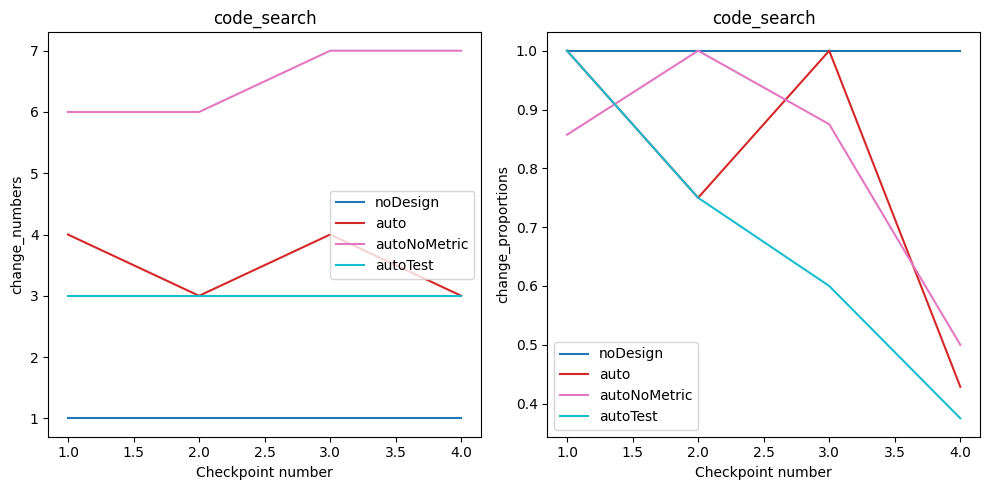

In [26]:
import os 
from metrics.change_coupling.overall_metrics import get_added_files, get_changed_files, get_deleted_files, get_all_modules, get_change_coupling

# data is in the form of [[{...}, {...}], [... ]]
data = []

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 

    checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
    checkpoint_dirs.sort() 

    data_mode = [] 
    # Walk through each checkpoint in pairs 
    for i in range(1, len(checkpoint_dirs)): 
        prev_impl_dir = dirs[mode_no] / checkpoint_dirs[i-1]
        impl_dir = dirs[mode_no] / checkpoint_dirs[i]

        # With respect to the prev impl and the current impl dir: determine the files that are added / changed / deleted 
        changed = get_changed_files(prev_impl_dir, impl_dir)
        total = get_all_modules(prev_impl_dir)
        print(f"{prev_impl_dir}->{impl_dir}: {get_changed_files(prev_impl_dir, impl_dir)}")

        data_mode.append({
            "change_numbers": len(changed), 
            "change_proportions": len(changed) / len(total)
        })

    data.append(data_mode)

    # print the change coupling metric 
    impl_dirs = [dirs[mode_no] / x for x in checkpoint_dirs]
    print(impl_dirs)
    print('\n'.join([str(x) for x in (get_change_coupling(impl_dirs)["pairs"])]))
    print(get_change_coupling(impl_dirs)["score"])

# plot 
list_plot(data, ["change_numbers", "change_proportions"])


## Added and changed lines

In [ ]:
import os 
from metrics.change_coupling.overall_metrics import get_added_deleted_lines

# data is in the form of [[{...}, {...}], [... ]]
data = []

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 

    checkpoint_dirs = [x for x in checkpoint_dirs if x.startswith("checkpoint_")]
    checkpoint_dirs.sort() 

    data_mode = [] 
    # Walk through each checkpoint in pairs 
    for i in range(1, len(checkpoint_dirs)): 
        prev_impl_dir = dirs[mode_no] / checkpoint_dirs[i-1]
        impl_dir = dirs[mode_no] / checkpoint_dirs[i]

        # With respect to the prev impl and the current impl dir: determine the files that are added / changed / deleted 
        tmp = get_added_deleted_lines(old_dir=prev_impl_dir, new_dir=impl_dir) 
        data_mode.append({
            "churn": tmp["added"]+tmp["deleted"], 
            "churn_proportion": (tmp["added"]+tmp["deleted"]) / tmp["old_loc"] if tmp["old_loc"] > 0 else 0, 
            "deleted_proportion": (tmp["deleted"]) / tmp["old_loc"] if tmp["old_loc"] > 0 else 0, 
        })

    data.append(data_mode)

print(data)
plot(data, ["churn", "churn_proportion", "deleted_proportion"])

## Token counts in the impl stage

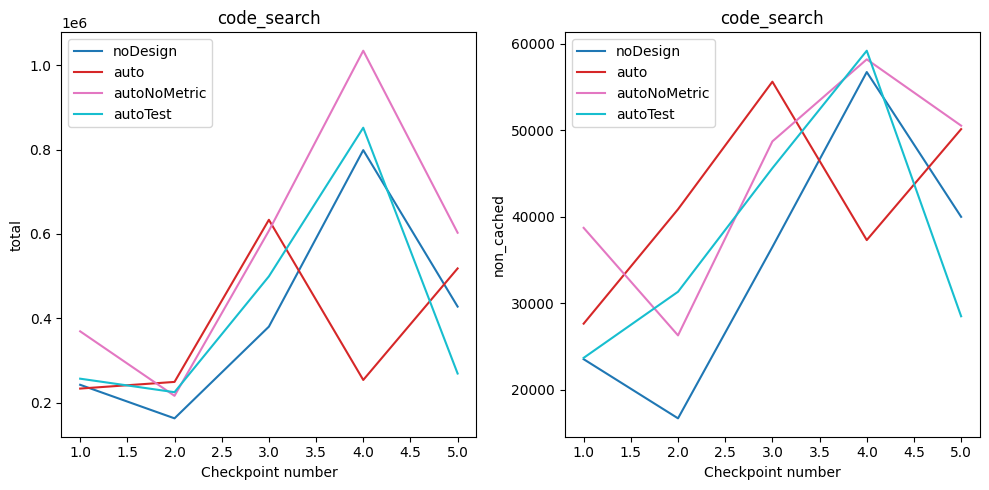

In [28]:
plot(scb_report_metrics, ["total", "non_cached"])

## LOC

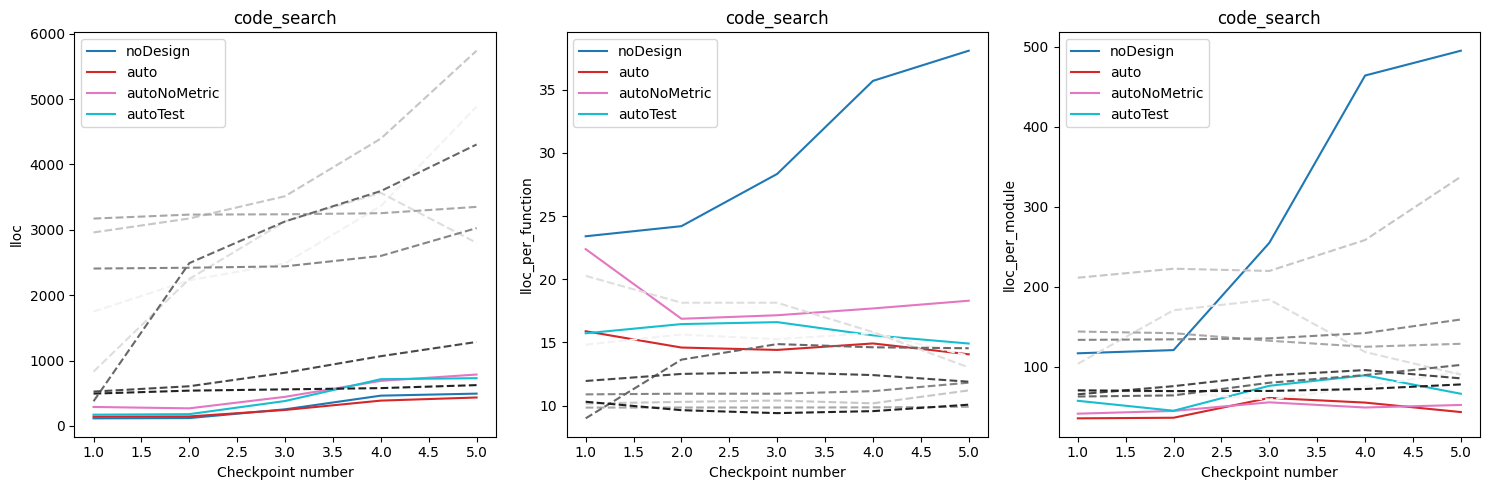

In [29]:
plot(scb_metrics, ["lloc", "lloc_per_function", "lloc_per_module"], with_references=True)

## High CC functions and High LOC functions

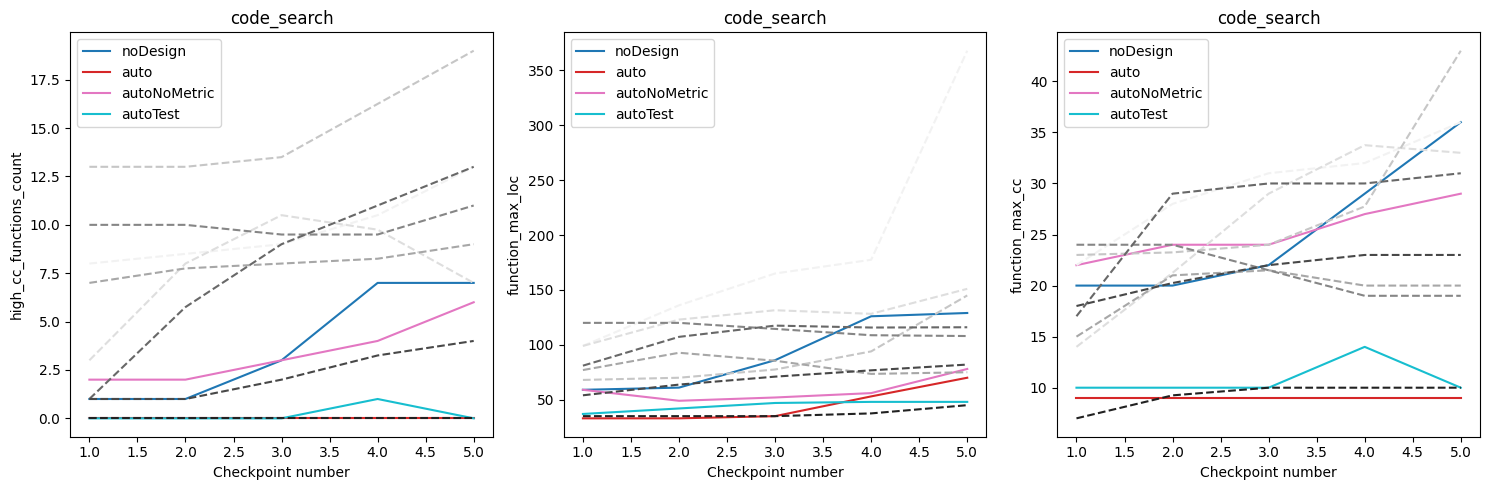

In [30]:
plot(scb_metrics, ["high_cc_functions_count", "function_max_loc", "function_max_cc"], with_references=True)

## Weighted MI

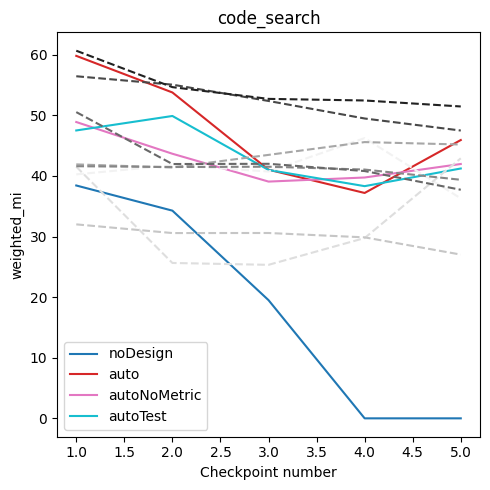

In [31]:
plot(scb_metrics, ["weighted_mi"], with_references=True)

## Duplicated lines and tokens

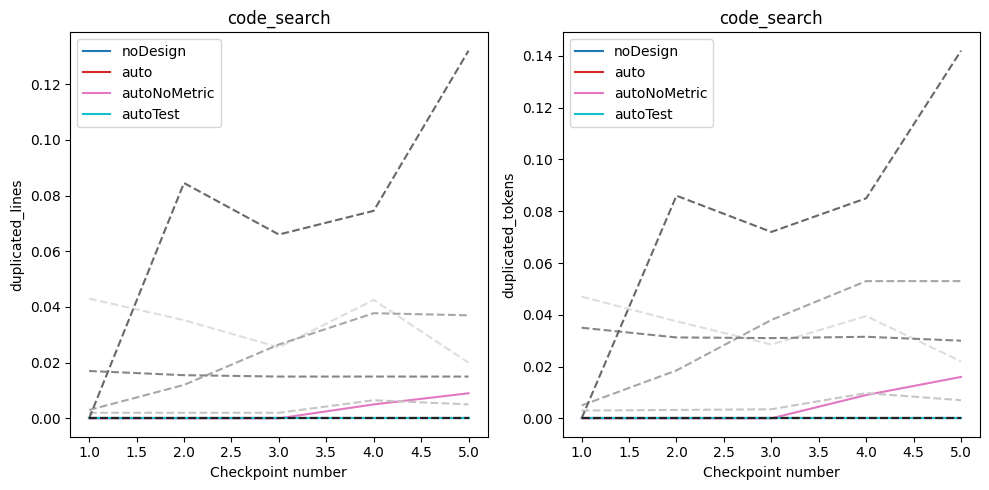

In [40]:
plot(scb_metrics, ["duplicated_lines", "duplicated_tokens"], with_references=True)

## Graph average degree

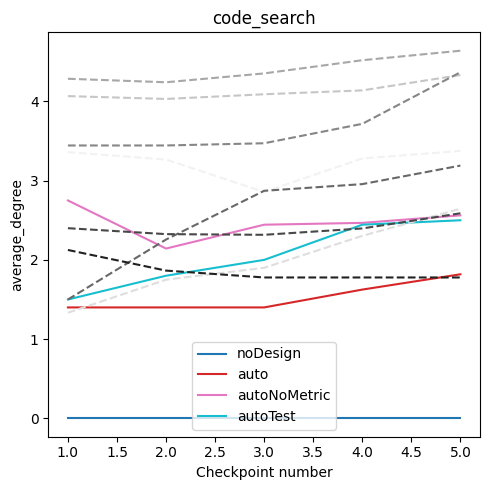

In [34]:
plot(scb_metrics, ["average_degree"], with_references=True)

## Number of public methods per module

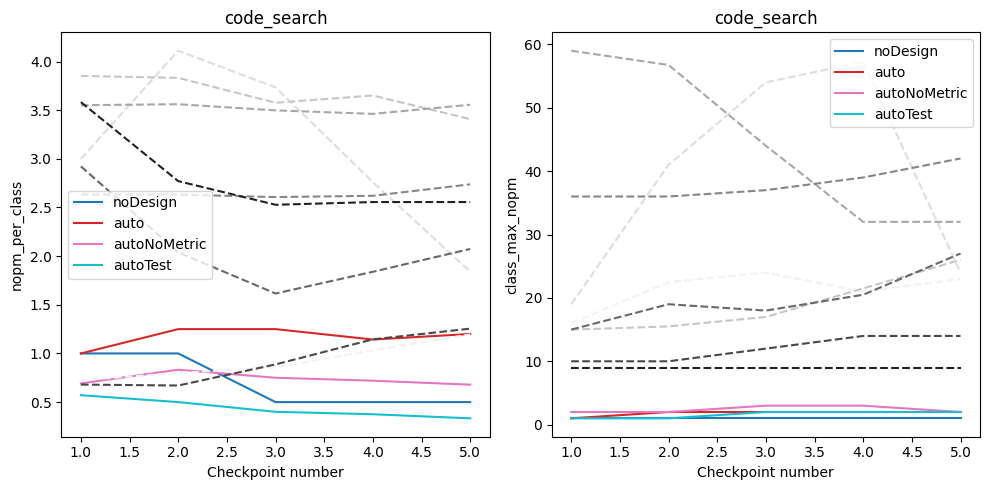

In [35]:
plot(scb_metrics, ["nopm_per_class", "class_max_nopm"], with_references=True)

## Number of functions (per module)

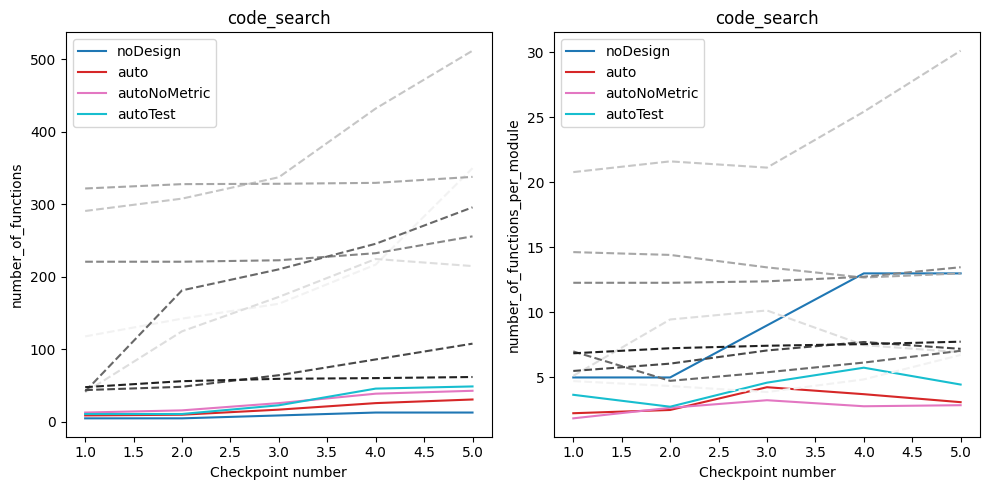

In [36]:
plot(scb_metrics, ["number_of_functions", "number_of_functions_per_module"], with_references=True)

## N, Prop cost, impact size

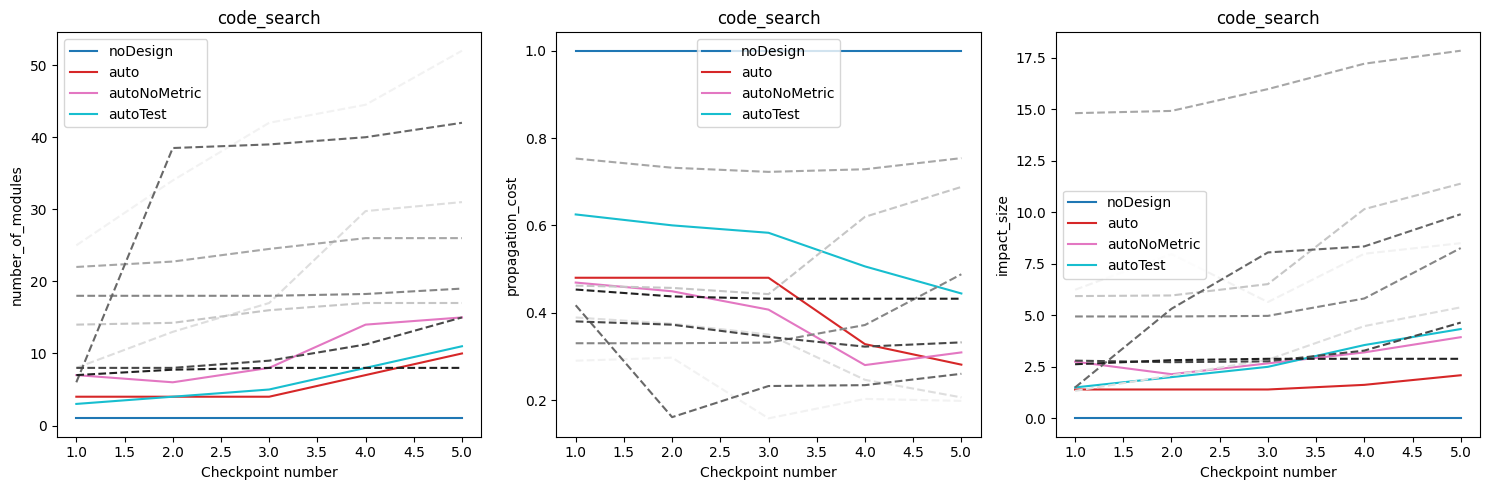

In [37]:
plot(scb_metrics, ["number_of_modules", "propagation_cost", "impact_size"], with_references=True)

## Tests pass rate

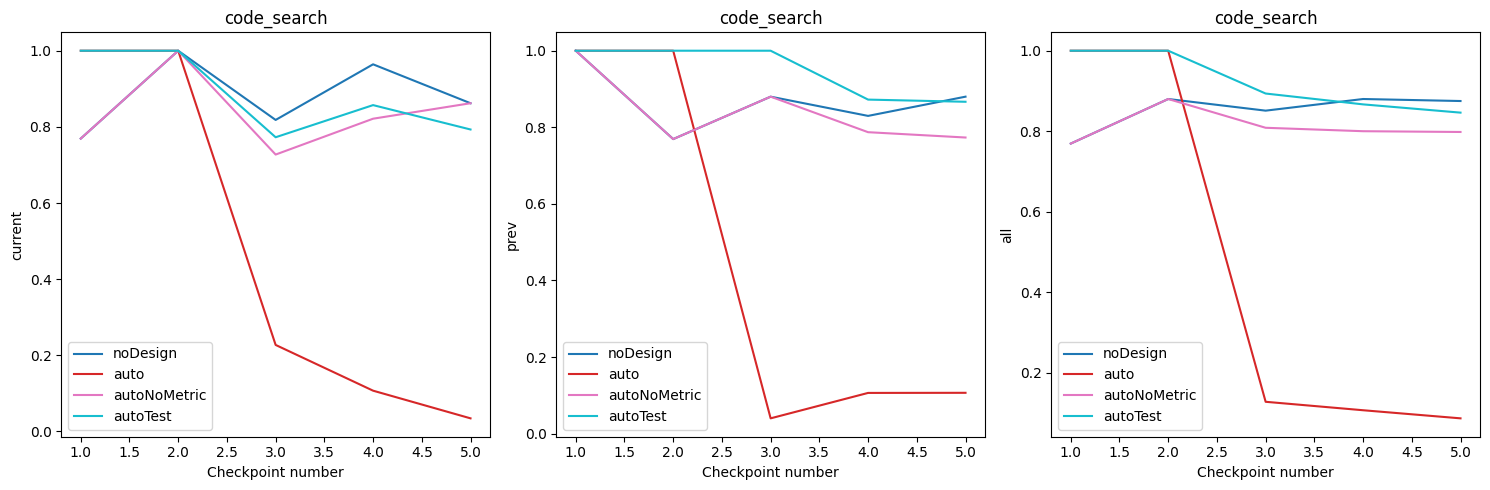

In [38]:
if TYPE == "scb": 
    plot(
        scb_test_metrics, 
        ["current", "prev", "all"]
    )